In [39]:
import os
import sys
sys.path.append('..')

import pandas as pd
import geopandas as gpd

import config as cfg

In [40]:
gdf = gpd.read_file(os.path.join(cfg.DATA_PATH, 'Results', 'region2_results_gdf.geojson'))
gdf

,ADM2_EN,population,lit_per_area,mean_temperature,Recommended Production Value (2015),Recommended Production Value (2016),Recommended Production Value (2017),Recommended Production Value (2018),Recommended Production Value (2019),Recommended Production Value (2020),Recommended Production Volume (2015),Recommended Production Volume (2016),Recommended Production Volume (2017),Recommended Production Volume (2018),Recommended Production Volume (2019),Recommended Production Volume (2020),geometry
0,Batanes,18831,51.170893,24.891143,5.288797e+04,4.511687e+04,4.971824e+04,5.216975e+04,5.449336e+04,6.148347e+04,507.330802,408.373973,442.061083,441.478453,446.596563,430.343172,"MULTIPOLYGON (((121.886 20.290, 121.886 20.290..."
1,Cagayan,1268603,49.406504,25.710113,4.000095e+06,3.836400e+06,3.860057e+06,3.733078e+06,3.696845e+06,3.797041e+06,44473.909989,41719.144643,38995.521198,36181.428626,33804.981228,32579.166793,"MULTIPOLYGON (((121.600 17.548, 121.577 17.555..."
2,Isabela,1697050,47.967070,25.797303,1.081956e+06,1.030461e+06,1.068705e+06,1.022465e+06,1.008484e+06,1.030699e+06,12082.566119,11774.099423,11836.433358,11123.000926,11204.875513,10882.020243,"MULTIPOLYGON (((121.576 16.594, 121.576 16.598..."
3,Nueva Vizcaya,497432,31.413241,22.381433,3.859473e+04,3.975561e+04,4.006495e+04,3.870376e+04,4.020209e+04,4.411507e+04,412.020706,437.967548,448.492947,426.471740,437.596006,457.695948,"POLYGON ((120.827 16.176, 120.815 16.181, 120...."
4,Quirino,203828,25.224881,24.097079,3.457196e+04,3.910150e+04,4.180849e+04,4.146160e+04,4.224269e+04,4.066636e+04,362.791176,425.422266,444.539608,417.734869,415.201304,384.837050,"POLYGON ((121.511 15.950, 121.505 15.949, 121...."


# Forecasting 2022

In [48]:
temp_gdf = gdf.set_index('ADM2_EN').T

years = []
template = 'Recommended Production Value ({})'
for year in range(2015, 2021):
    col_name = template.format(year)
    years.append(temp_gdf.loc[col_name])

vol_df = pd.concat(years, axis=1).T#.reset_index(drop=True)
vol_df.index = pd.date_range(start='2015', end='2021', freq='A')

vol_df_train = vol_df.iloc[:-2,:]
vol_df_val = vol_df.iloc[-2:,:]

vol_df_train

ADM2_EN,Batanes,Cagayan,Isabela,Nueva Vizcaya,Quirino
2015-12-31,52887.965422,4000095.399301,1081956.092034,38594.726987,34571.961647
2016-12-31,45116.865783,3836400.373305,1030461.086135,39755.608036,39101.500036
2017-12-31,49718.24285,3860056.999263,1068704.885678,40064.948664,41808.494431
2018-12-31,52169.747378,3733078.016539,1022464.577109,38703.76239,41461.598248


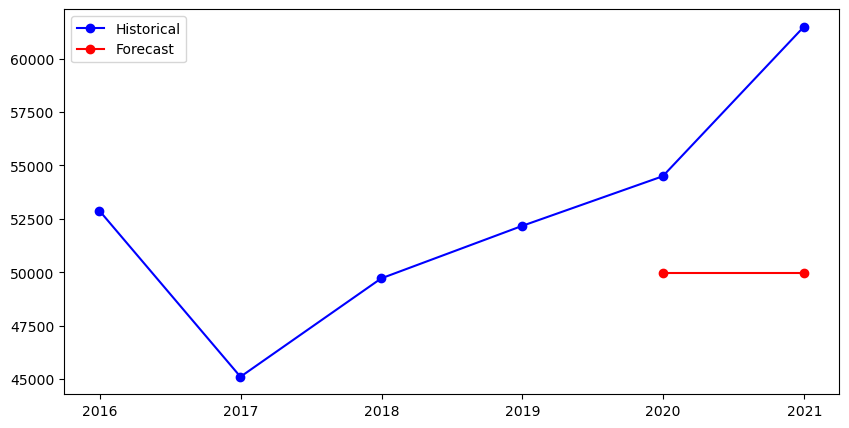

In [91]:
from statsmodels.tsa.api import SimpleExpSmoothing
import matplotlib.pyplot as plt

model1 = SimpleExpSmoothing(vol_df_train['Batanes'].to_numpy()).fit()
fcast1 = model1.forecast(2)

# Wrap Forecast
fcast1 = pd.DataFrame(fcast1)
fcast1.index = pd.date_range(start='2019', end='2021', freq='A')

# plot the Previous Data
plt.figure(figsize=(10, 5))
plt.plot(vol_df['Batanes'], label='Historical', color='blue', marker='o')
plt.plot(fcast1, label='Forecast', color='red', marker='o')
plt.legend()
plt.show()

c:\Users\paolo\anaconda3\envs\dsenv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


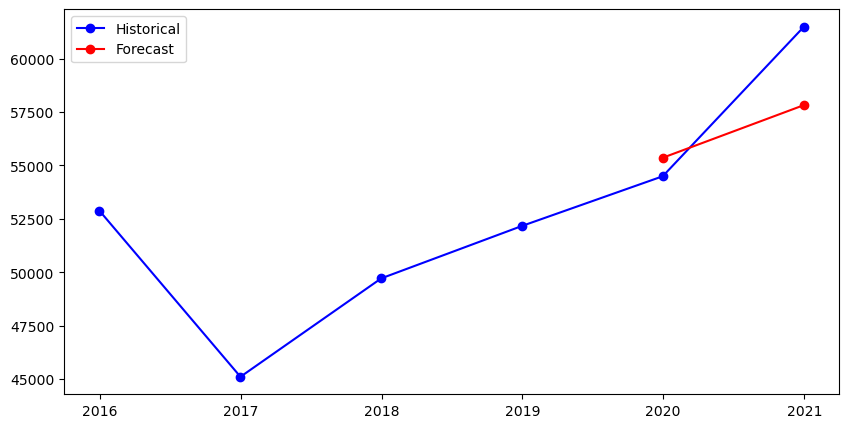

In [84]:
from statsmodels.tsa.api import Holt
import matplotlib.pyplot as plt

modelh = Holt(vol_df['Batanes'].to_numpy()).fit(smoothing_level=0.4)
fcasth = model1.forecast(2)

# Wrap Forecast
fcasth = pd.DataFrame(fcasth)
fcasth.index = pd.date_range(start='2019', end='2021', freq='A')

# plot the Previous Data
plt.figure(figsize=(10, 5))
plt.plot(vol_df['Batanes'], label='Historical', color='blue', marker='o')
plt.plot(fcasth, label='Forecast', color='red', marker='o')
plt.legend()
plt.show()

# Evaluating the Forecast

In [93]:
from sklearn.metrics import mean_absolute_error

holt_mse = mean_absolute_error(vol_df_val['Batanes'], fcasth)

holt_mse

2264.5009782004054

# Automating the Forecast

In [94]:
from statsmodels.tsa.api import Holt
import matplotlib.pyplot as plt

def forecast_until_2022(region, vol_df):
    model1 = Holt(vol_df[region].to_numpy()).fit(smoothing_level=0.4)
    fcast = model1.forecast(2)

    # Wrap Forecast
    fcast = pd.DataFrame(fcast, columns=[region])
    fcast.index = pd.date_range(start='2021', end='2023', freq='A')

    return fcast

def create_df_with_forecast(df, to_forecast):
    # Create vol_df
    temp_gdf = df.set_index('ADM2_EN').T
    years = []
    template = 'Recommended Production {} ({})'
    for year in range(2015, 2021):
        col_name = template.format(to_forecast, year)
        years.append(temp_gdf.loc[col_name])

    vol_df = pd.concat(years, axis=1).T
    vol_df.index = pd.date_range(start='2015', end='2021', freq='A')

    # Forecasting
    fcasts = []
    for region in df['ADM2_EN'].unique():
        fcast = forecast_until_2022(region, vol_df)
        fcasts.append(fcast)

    final_df = pd.concat([vol_df, pd.concat(fcasts, axis=1)]).reset_index()

    final_df['index'] = final_df['index'].dt.year
    final_df['index'] = final_df['index'].apply(lambda x: template.format(to_forecast, x) + ('' if x not in [2021, 2022] else ' - Forecasted'))

    final_df.set_index('index', inplace=True)

    final_df = final_df.T

    return final_df

forecast_df_Value = create_df_with_forecast(gdf, 'Value')
forecast_df_Volume = create_df_with_forecast(gdf, 'Volume')

gdf = gdf[[col for col in gdf.columns if not col.startswith('Recommended')]]
gdf.set_index('ADM2_EN',inplace=True)
gdf = pd.concat([gdf, forecast_df_Value], axis=1)
gdf = pd.concat([gdf, forecast_df_Volume], axis=1)

gdf

c:\Users\paolo\anaconda3\envs\dsenv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\paolo\anaconda3\envs\dsenv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\paolo\anaconda3\envs\dsenv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\paolo\anaconda3\envs\dsenv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,population,lit_per_area,mean_temperature,geometry,Recommended Production Value (2015),Recommended Production Value (2016),Recommended Production Value (2017),Recommended Production Value (2018),Recommended Production Value (2019),Recommended Production Value (2020),Recommended Production Value (2021) - Forecasted,Recommended Production Value (2022) - Forecasted,Recommended Production Volume (2015),Recommended Production Volume (2016),Recommended Production Volume (2017),Recommended Production Volume (2018),Recommended Production Volume (2019),Recommended Production Volume (2020),Recommended Production Volume (2021) - Forecasted,Recommended Production Volume (2022) - Forecasted
Batanes,18831,51.170893,24.891143,"MULTIPOLYGON (((121.886 20.290, 121.886 20.290...",52887.965422,45116.865783,49718.24285,52169.747378,54493.364443,61483.467569,55358.6691,57819.770269,507.330802,408.373973,442.061083,441.478453,446.596563,430.343172,419.494753,410.882728
Cagayan,1268603,49.406504,25.710113,"MULTIPOLYGON (((121.600 17.548, 121.577 17.555...",4000095.399301,3836400.373305,3860056.999263,3733078.016539,3696844.997229,3797040.688632,3630286.568164,3598858.320985,44473.909989,41719.144643,38995.521198,36181.428626,33804.981228,32579.166793,29565.823303,27149.11753
Isabela,1697050,47.967070,25.797303,"MULTIPOLYGON (((121.576 16.594, 121.576 16.598...",1081956.092034,1030461.086135,1068704.885678,1022464.577109,1008483.985503,1030698.963157,991196.996557,983951.557086,12082.566119,11774.099423,11836.433358,11123.000926,11204.875513,10882.020243,10645.153324,10405.519683
Nueva Vizcaya,497432,31.413241,22.381433,"POLYGON ((120.827 16.176, 120.815 16.181, 120....",38594.726987,39755.608036,40064.948664,38703.76239,40202.089277,44115.066247,43156.66674,43964.318571,412.020706,437.967548,448.492947,426.47174,437.596006,457.695948,458.397312,464.685845
Quirino,203828,25.224881,24.097079,"POLYGON ((121.511 15.950, 121.505 15.949, 121....",34571.961647,39101.500036,41808.494431,41461.598248,42242.692659,40666.357292,45044.045544,45823.359162,362.791176,425.422266,444.539608,417.734869,415.201304,384.83705,408.52173,410.41314


# Generate Recommendations

In [96]:
def create_recommendation(row):
    if (row[r'Recommended Production Value (2022) - Forecasted'] < 0 and row[r'Recommended Production Volume (2022) - Forecasted'] < 0):
        row['Recommendation'] = 'Decrease Fishing Activity'
    elif (row[r'Recommended Production Value (2022) - Forecasted'] > 0 and row[r'Recommended Production Volume (2022) - Forecasted'] < 0):
        row['Recommendation'] = 'Decrease Fishing Activity (Keep Price)'
    elif (row[r'Recommended Production Value (2022) - Forecasted'] < 0 and row[r'Recommended Production Volume (2022) - Forecasted'] > 0):
        row['Recommendation'] = 'Increase Fishing Activity (Lower Price)'
    else:
        row['Recommendation'] = 'Increase Fishing Activity'
    return row

forecast_changes_Value = forecast_df_Value.T.pct_change().T
forecast_changes_Volume = forecast_df_Volume.T.pct_change().T

forecast_changes = pd.concat([forecast_changes_Value, forecast_changes_Volume], axis=1)

# forecast_changes
forecast_changes = forecast_changes.apply(create_recommendation, axis=1)

gdf['Recommendation'] = forecast_changes['Recommendation']

gdf

,population,lit_per_area,mean_temperature,geometry,Recommended Production Value (2015),Recommended Production Value (2016),Recommended Production Value (2017),Recommended Production Value (2018),Recommended Production Value (2019),Recommended Production Value (2020),...,Recommended Production Value (2022) - Forecasted,Recommended Production Volume (2015),Recommended Production Volume (2016),Recommended Production Volume (2017),Recommended Production Volume (2018),Recommended Production Volume (2019),Recommended Production Volume (2020),Recommended Production Volume (2021) - Forecasted,Recommended Production Volume (2022) - Forecasted,Recommendation
Batanes,18831,51.170893,24.891143,"MULTIPOLYGON (((121.886 20.290, 121.886 20.290...",52887.965422,45116.865783,49718.24285,52169.747378,54493.364443,61483.467569,...,57819.770269,507.330802,408.373973,442.061083,441.478453,446.596563,430.343172,419.494753,410.882728,Decrease Fishing Activity (Keep Price)
Cagayan,1268603,49.406504,25.710113,"MULTIPOLYGON (((121.600 17.548, 121.577 17.555...",4000095.399301,3836400.373305,3860056.999263,3733078.016539,3696844.997229,3797040.688632,...,3598858.320985,44473.909989,41719.144643,38995.521198,36181.428626,33804.981228,32579.166793,29565.823303,27149.11753,Decrease Fishing Activity
Isabela,1697050,47.967070,25.797303,"MULTIPOLYGON (((121.576 16.594, 121.576 16.598...",1081956.092034,1030461.086135,1068704.885678,1022464.577109,1008483.985503,1030698.963157,...,983951.557086,12082.566119,11774.099423,11836.433358,11123.000926,11204.875513,10882.020243,10645.153324,10405.519683,Decrease Fishing Activity
Nueva Vizcaya,497432,31.413241,22.381433,"POLYGON ((120.827 16.176, 120.815 16.181, 120....",38594.726987,39755.608036,40064.948664,38703.76239,40202.089277,44115.066247,...,43964.318571,412.020706,437.967548,448.492947,426.47174,437.596006,457.695948,458.397312,464.685845,Increase Fishing Activity
Quirino,203828,25.224881,24.097079,"POLYGON ((121.511 15.950, 121.505 15.949, 121....",34571.961647,39101.500036,41808.494431,41461.598248,42242.692659,40666.357292,...,45823.359162,362.791176,425.422266,444.539608,417.734869,415.201304,384.83705,408.52173,410.41314,Increase Fishing Activity


# Df with Forecast and Recommendation

In [97]:
gdf.to_file(os.path.join(cfg.DATA_PATH, 'Results', 'region2_results_gdf_with_forecast_and_recommendation.geojson'))